# Dev Results Comparison - Banking Intent Classification

This notebook compares dev set results across the experiments saved

## Setup and loading

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

from intent_classification.config import RESULTS_DIR


sns.set_theme(style='whitegrid')

## Results Overview

### Available experiments

In [2]:
dev_paths = sorted(
    RESULTS_DIR.glob('*/dev.csv'),
    key=lambda p: p.relative_to(RESULTS_DIR).parts,
)

pd.DataFrame(
    {
        'experiment': path.parent.name,
        'rows': len(df := pd.read_csv(path)),
        'columns': ', '.join(df.columns),
    }
    for path in dev_paths
)

,experiment,rows,columns
0,llm-fewshot-qwen2.5:3b-instruct-q4_k_m,250,"model, text, y_true, y_pred"
1,llm-oneshot-qwen2.5:3b-instruct-q4_k_m,250,"model, text, y_true, y_pred"
2,llm-rag-qwen2.5:3b-instruct-q4_k_m,250,"model, text, y_true, y_pred"
3,llm-sft-local-qwen-qwen2.5-0.5b-instruct,250,"model, text, y_true, y_pred"
4,llm-zeroshot-qwen2.5:3b-instruct-q4_k_m,250,"model, text, y_true, y_pred"


### Metrics summary

In [3]:
rows = []
for path in dev_paths:
    df = pd.read_csv(path)
    rows.append({
        'experiment': path.parent.name,
        'samples': len(df),
        'accuracy': accuracy_score(df['y_true'], df['y_pred']),
        'precision': precision_score(df['y_true'], df['y_pred'], average='macro', zero_division=0),
        'recall': recall_score(df['y_true'], df['y_pred'], average='macro', zero_division=0),
        'f1': f1_score(df['y_true'], df['y_pred'], average='macro', zero_division=0),
    })

summary = pd.DataFrame(rows).sort_values('f1', ascending=False).round(2)
summary

,experiment,samples,accuracy,precision,recall,f1
2,llm-rag-qwen2.5:3b-instruct-q4_k_m,250,0.78,0.79,0.78,0.78
1,llm-oneshot-qwen2.5:3b-instruct-q4_k_m,250,0.70,0.73,0.70,0.70
0,llm-fewshot-qwen2.5:3b-instruct-q4_k_m,250,0.69,0.74,0.70,0.70
4,llm-zeroshot-qwen2.5:3b-instruct-q4_k_m,250,0.64,0.68,0.64,0.64
3,llm-sft-local-qwen-qwen2.5-0.5b-instruct,250,0.44,0.55,0.47,0.44


## Model Comparison

### Metric ranking

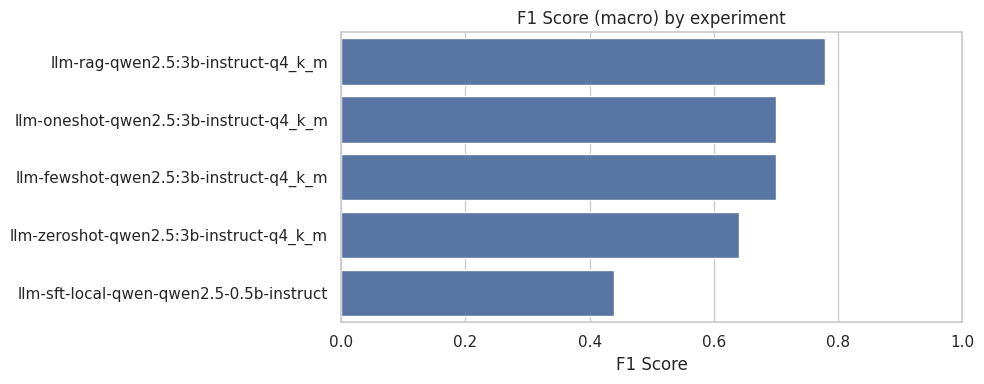

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=summary.reset_index(), y='experiment', x='f1', ax=ax)
ax.set_title('F1 Score (macro) by experiment')
ax.set_xlabel('F1 Score')
ax.set_ylabel('')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

### Confusion matrices

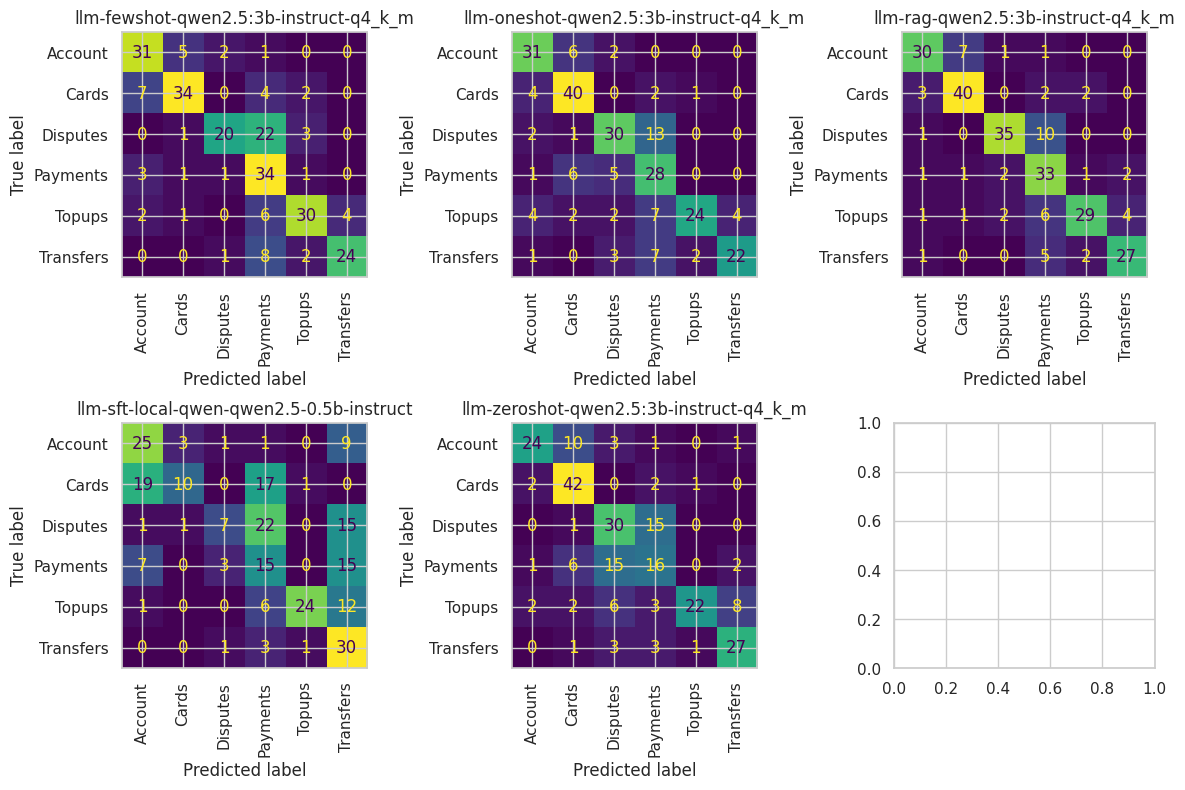

In [5]:
cols = 3
rows = math.ceil(len(dev_paths) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, p in zip(axes, dev_paths):
    df = pd.read_csv(p)
    true_labels = sorted(df['y_true'].unique())
    y_pred = df['y_pred'].where(df['y_pred'].isin(true_labels), other='(other)')
    labels = true_labels + (['(other)'] if y_pred.eq('(other)').any() else [])

    disp = ConfusionMatrixDisplay.from_predictions(
        df['y_true'], y_pred,
        labels=labels,
        display_labels=labels,
        ax=ax,
        values_format='d',
        colorbar=False,
        xticks_rotation='vertical',
    )
    ax.set_title(p.parent.name)

plt.tight_layout()
plt.show()